In [1]:
import json
import os
from pathlib import Path
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

dirpath_repo_root = Path().resolve().parents[1]
dirpath_self = Path().resolve().parent
sys.path.append(str(dirpath_repo_root))
sys.path.append(str(dirpath_self))

from analysis.ou_tuning import batch_utils

In [2]:
def _get_fpath_by_templ(dirpath: Path, fname_templ: str) -> str:
    files = list(dirpath.glob(fname_templ))
    if len(files) != 1:
        print(f'Path for search: {str(dirpath)}')
        print(f'Name template: {fname_templ}')
        raise RuntimeError('Should be exactly one filename match')
    return files[0]

### 1D batch (rxe)

In [12]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/it2_nosub_wmult_var_rxe'
exp_name_sub = 'exp_IT2_t_3.0_5.0_rxi_10000.0_wx_0.1_0.1_wmult_0.25'

dirpath_res = dirpath_repo_root / 'exp_results' / exp_name

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'rxe': 'rxe'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
#job_idx_xr

In [ ]:
dirpath_data = dirpath_res / exp_name_sub / 'results'
fname_data_templ = 'result_{job:05d}_*.json'
    
# Test: find the data file for job_id=0a
fname_data = fname_data_templ.format(job=0)
fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)   # resolve * in fname_data
fpath_data.name

'result_00000_rxe_10000.0.json'

In [14]:
pops_used = ['IT2', 'IT6frz']
vars = {'rate': 'rates', 'cv': 'cvs'}

dims_new = list(job_idx_xr.dims) + ['pop']
coords_new = dict(job_idx_xr.coords) | {'pop': pops_used}
sz_new = [job_idx_xr.sizes[d] for d in job_idx_xr.dims] + [len(pops_used)]

X = {}
Z = xr.DataArray(np.full(sz_new, np.nan),
                 dims=dims_new, coords=coords_new)
for v in vars:
    X[v] = Z.copy()
X = xr.Dataset(X)
#X

In [15]:
# Iterate over all cells in job_idx_xr
for idx in np.ndindex(job_idx_xr.shape):
    job_id = job_idx_xr.values[idx]
    
    # Generate file path for the job data
    fname_data = fname_data_templ.format(job=job_id)
    fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
    #print(job_id, fpath_data.name)

    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}

    # Load data and assign it to the corresponding slice in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            X[v][sel].loc[{'pop': pop}] = res[v_res][pop]

Text(0.5, 1.0, 'CV, IT2')

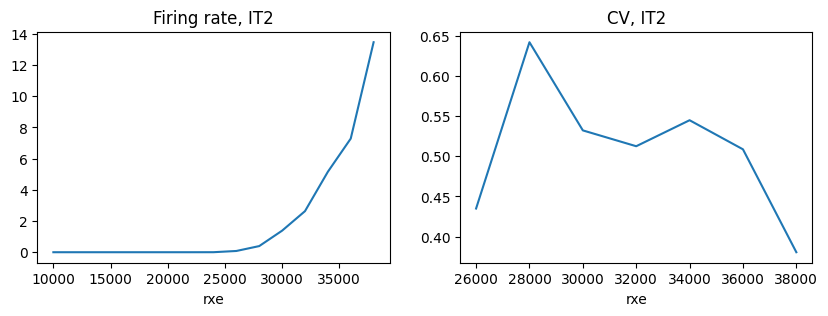

In [16]:
pop = pops_used[0]
r = X['rate'].sel(pop=pop)
cv = X['cv'].sel(pop=pop)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(r.rxe, r)
plt.xlabel('rxe')
plt.title(f'Firing rate, {pop}')
plt.subplot(1, 2, 2)
plt.plot(r.rxe, cv)
plt.xlabel('rxe')
plt.title(f'CV, {pop}')

### 2D batch (drxe, rxi)

In [3]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/pops_wmult_var_drxe_rxi'

exp_name_sub = 'exp_som_t_3.0_5.0_wx_0.5_1_sz_10_10_wmult_0.25_ee_0.5_subcon_1'
pops_used = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']

#exp_name_sub = 'exp_pv_t_3.0_5.0_wx_0.5_1_sz_10_10_wmult_0.25_ee_0.5_subcon_1'
#pops_used = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']

#exp_name_sub = 'exp_ngf_t_3.0_5.0_wx_0.5_1_sz_5_5_wmult_0.25_ee_0.5_subcon_1'
#pops_used = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

dirpath_res = dirpath_repo_root / 'exp_results' / exp_name
dirpath_data = dirpath_res / exp_name_sub / 'results'
fname_data_templ = 'result_{job:05d}_*.json'

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'drxe_pos': 'drxe_pos', 'rxi_pos': 'rxi_pos'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
job_idx_xr

<xarray.DataArray 'job_id' (drxe_pos: 10, rxi_pos: 10)> Size: 800B
array([[nan, nan, nan, 30., 40., 50., 60., 70., 80., 90.],
       [nan, nan, 21., 31., 41., 51., 61., 71., 81., 91.],
       [nan, nan, 22., 32., 42., 52., 62., 72., 82., 92.],
       [nan, nan, 23., 33., 43., 53., 63., 73., 83., 93.],
       [nan, 14., 24., 34., 44., 54., 64., 74., 84., 94.],
       [nan, 15., 25., 35., 45., 55., 65., 75., 85., 95.],
       [nan, 16., 26., 36., 46., 56., 66., 76., 86., 96.],
       [ 7., 17., 27., 37., 47., 57., 67., 77., 87., 97.],
       [ 8., 18., 28., 38., 48., 58., 68., 78., 88., 98.],
       [ 9., 19., 29., 39., 49., 59., 69., 79., 89., 99.]])
Coordinates:
  * drxe_pos  (drxe_pos) float64 80B 0.0 0.1111 0.2222 ... 0.7778 0.8889 1.0
  * rxi_pos   (rxi_pos) float64 80B 0.0 0.1111 0.2222 ... 0.7778 0.8889 1.0

In [4]:
vars = {
    'rate': 'rates', 'cv': 'cvs',
    'vmin': 'v_med_min', 'vmax': 'v_med_max',
    'vavg': 'v_med_avg'
}

dims_new = list(job_idx_xr.dims) + ['pop']
coords_batch = {k: v.astype(float) for k, v in job_idx_xr.coords.items()}
coords_new = coords_batch | {'pop': pops_used}
sz_new = [job_idx_xr.sizes[d] for d in job_idx_xr.dims] + [len(pops_used)]

X = {}
Z = xr.DataArray(np.full(sz_new, np.nan),
                 dims=dims_new, coords=coords_new)
for v in vars:
    X[v] = Z.copy()
X = xr.Dataset(X)

# Iterate over all cells in job_idx_xr
for idx in np.ndindex(job_idx_xr.shape):
    job_id = job_idx_xr.values[idx]
    if np.isnan(job_id):
        continue
    job_id = int(job_id)
    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}
    
    # Generate file path for the job data
    fname_data = fname_data_templ.format(job=job_id)
    fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
    #print(job_id, fpath_data.name)

    # Load data and assign it to the corresponding slice in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            X[v][sel].loc[{'pop': pop}] = res[v_res][pop]
X

<xarray.Dataset> Size: 24kB
Dimensions:   (drxe_pos: 10, rxi_pos: 10, pop: 6)
Coordinates:
  * drxe_pos  (drxe_pos) float64 80B 0.0 0.1111 0.2222 ... 0.7778 0.8889 1.0
  * rxi_pos   (rxi_pos) float64 80B 0.0 0.1111 0.2222 ... 0.7778 0.8889 1.0
  * pop       (pop) <U5 120B 'SOM2' 'SOM3' 'SOM4' 'SOM5A' 'SOM5B' 'SOM6'
Data variables:
    rate      (drxe_pos, rxi_pos, pop) float64 5kB nan nan nan ... 1.205 0.5317
    cv        (drxe_pos, rxi_pos, pop) float64 5kB nan nan nan ... 0.6977 0.5827
    vmin      (drxe_pos, rxi_pos, pop) float64 5kB nan nan nan ... -41.63 -42.74
    vmax      (drxe_pos, rxi_pos, pop) float64 5kB nan nan nan ... -38.3 -38.93
    vavg      (drxe_pos, rxi_pos, pop) float64 5kB nan nan nan ... -39.89 -40.44

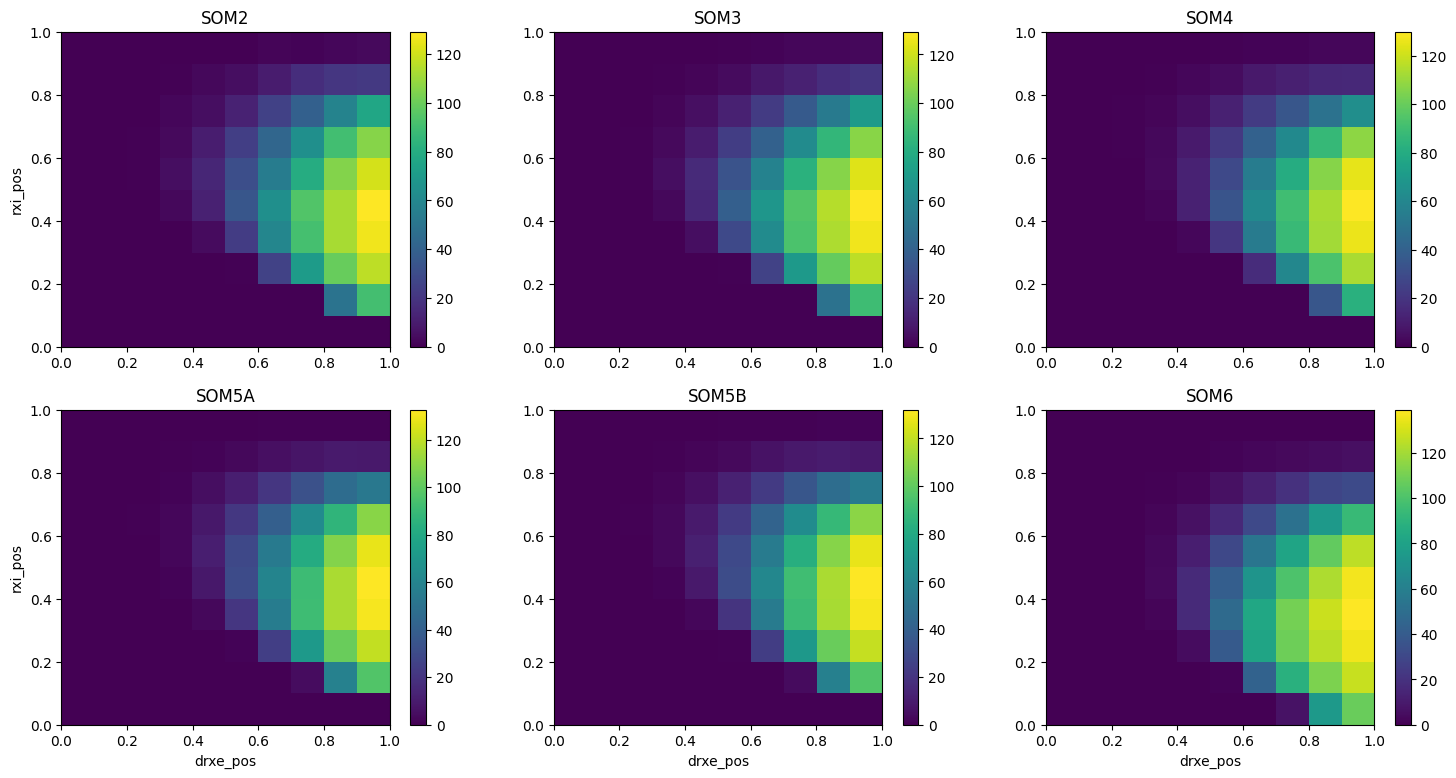

In [24]:
xname, yname = 'drxe_pos', 'rxi_pos'
k = 1

x0, x1 = float(X[xname].min()) * k, float(X[xname].max()) * k
y0, y1 = float(X[yname].min()) * k, float(X[yname].max()) * k

plt.figure(figsize=(18, 9))

for n, pop in enumerate(pops_used):
    r = X['rate'].sel(pop=pop)
    r.values[np.isnan(r)] = 0

    plt.subplot(2, 3, n + 1)
    plt.imshow(r.T, extent=(x0, x1, y0, y1),
               aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar()
    plt.title(pop)
    if n in [3, 4, 5]:
        plt.xlabel(xname)
    if n in [0, 3]:
        plt.ylabel(yname)


In [21]:
X['rate'].isel(pop=0)

<xarray.DataArray 'rate' (drxe_pos: 10, rxi_pos: 10)> Size: 800B
array([[0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e-01, 0.000e+00, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e-01, 0.000e+00, 0.000e+00, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e-01, 7.000e-01,
        1.000e+00, 4.000e-01, 2.000e-01, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 1.000e-01, 2.600e+00, 4.600e+00,
        3.500e+00, 2.100e+00, 9.000e-01, 4.000e-01],
       [0.000e+00, 0.000e+00, 0.000e+00, 3.700e+00, 1.210e+01, 1.390e+01,
        1.020e+01, 4.700e+00, 3.000e+00, 4.000e-01],
       [0.000e+00, 0.000e+00, 7.000e-01, 2.300e+01, 3.460e+01, 3.100e+01,
        2.410e+01, 1.250e+01, 4.900e+00, 2.000e-01],
       [0.000e+00, 0.000e+00, 2.550e+01, 5.940e+01, 6.430e+01, 5.430e+01,
        4.280e+01, 2.490e+01, 9.900e+00, 1.900e+00],
       [0.000e+00, 0.000e+00, 7.110e+01, 9.110e+01, 9.430e+01, 8.000e+01,
        6.420e+01, 3.960e+01, 1.680e+01, 1.500e+00],
       [0.000e+00, 4.920e+01, 9.910e+01, 1.124e+02, 1.123e+02, 1.052e+02,
        9.000e+01, 5.760e+01, 2.030e+01, 2.500e+00],
       [0.000e+00, 9.070e+01, 1.166e+02, 1.264e+02, 1.293e+02, 1.208e+02,
        1.058e+02, 7.650e+01, 2.150e+01, 3.200e+00]])
Coordinates:
  * drxe_pos  (drxe_pos) float64 80B 0.0 0.1111 0.2222 ... 0.7778 0.8889 1.0
  * rxi_pos   (rxi_pos) float64 80B 0.0 0.1111 0.2222 ... 0.7778 0.8889 1.0
    pop       <U5 20B 'SOM2'

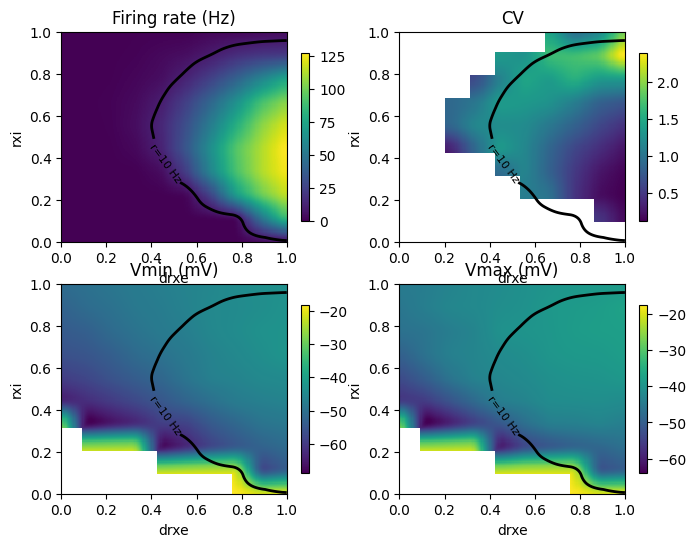

In [28]:
pop = pops_used[0]
X_ = [X[v].sel(pop=pop, drop=True) for v in vars]

x0, x1 = float(X[xname].min()) * k, float(X[xname].max()) * k
y0, y1 = float(X[yname].min()) * k, float(X[yname].max()) * k

# Upsample
N = 200
drxe_range = (x0, x1)
rxi_range = (y0, y1)
drxe_new = np.linspace(*drxe_range, N)
rxi_new  = np.linspace(*rxi_range, N)
sz = dict({xname: drxe_new, yname: rxi_new})
X_ = [x_.interp(**sz) for x_ in X_]

# Rescale coords for visualization
x0, x1 = drxe_range[0] * k, drxe_range[1] * k
y0, y1 = rxi_range[0] * k, rxi_range[1] * k

# Smooth data
w = 9
win = {'drxe_pos': w, 'rxi_pos': w}
def smooth(x):
    return x.rolling(**win, center=True, min_periods=1).mean()
X_ = [smooth(x_) for x_ in X_]

r, cv, vmin, vmax, vavg = X_

# Rate data used for contour selection
x_coords = r[xname].values * k
y_coords = r[yname].values * k
Xg, Yg = np.meshgrid(x_coords, y_coords)
Z = np.ma.masked_invalid(r.values.T)  # match imshow transpose, mask NaNs

# Contour level
r0 = 10

fig, axs = plt.subplots(2, 2, figsize=(8, 6))
plots = [
    ("Firing rate (Hz)", r),
    ("CV", cv),
    ("Vmin (mV)", vmin),
    ("Vmax (mV)", vmax),
]

for ax, (title, da) in zip(axs.ravel(), plots):
    # Metric heatmap
    im = ax.imshow(da.T, extent=(x0, x1, y0, y1),
                   aspect='auto', origin='lower', interpolation='nearest')

    # Contour: r=r0
    cs = ax.contour(Xg, Yg, Z, levels=[r0], colors='k', linewidths=2)
    ax.clabel(cs, fmt={r0: f"r={r0} Hz"}, inline=True, fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('drxe')
    ax.set_ylabel('rxi')
    fig.colorbar(im, ax=ax, shrink=0.8)


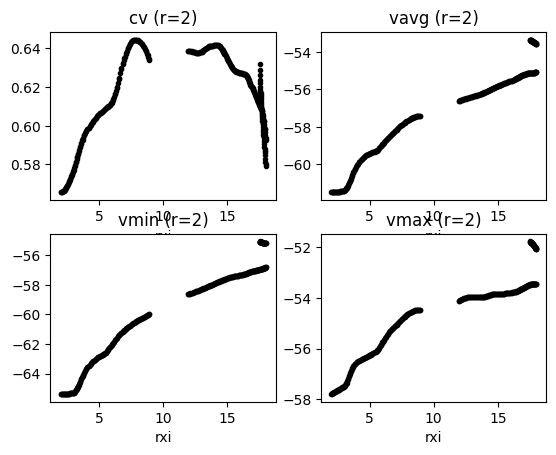

In [84]:
from scipy.interpolate import RegularGridInterpolator

Y_vars = {'cv': cv, 'vavg': vavg, 
          'vmin': vmin, 'vmax': vmax}

plt.figure()

for n, (v, Y_) in enumerate(Y_vars.items()):

    Y = np.array(Y_.values.T, dtype=float)
    interp = RegularGridInterpolator(
        (y_coords, x_coords), Y,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    
    plt.subplot(2, 2, n + 1)

    for cont in cs.allsegs[0]:
        drxe_c = cont[:, 0]
        rxi_c  = cont[:, 1]
        Yc = interp(np.c_[rxi_c, drxe_c])
        plt.plot(rxi_c, Yc, 'k.')

    plt.xlabel('rxi')
    plt.title(f'{v} (r={r0})')

In [85]:
k0, k1 = 6812.5, 2.0625
rxi_ = 12.5e3
drxe_ = -8e3
rxe_ = k0 + k1 * rxi_ + drxe_
rxe_

24593.75

### 2D batch (rxe, rxi)

In [113]:
exp_name = 'batch_rxbkg_unconn_state1_mech1/pops_inpsur_newsec_var_rxe_rxi'

#exp_name_sub = 'exp_pyr2456_wx_0.65_2.5_sz_7_7_t_3.0_5.0_rxmax_30000_3500_wmult_0.25_ee_0.5_lensec_1'
#pops_used = ['IT2', 'ITS4', 'ITP4', 'IT5A', 'CT5A', 'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6']

#exp_name_sub = 'exp_it5a_nosurr_wx_0.05_0.25_sz_5_5_rxmax_100.0_6.0_rxmin_0.1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_1'
#pops_used = ['IT5A']

#exp_name_sub = '2d_psp_0.5/pv/exp_pv_wx_0.25_2_sz_20_20_rxmax_10.0_2.0_rxmin_1_500_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_1_xsec_dend_soma'
exp_name_sub = 'exp_som_wx_0.25_0.55_sz_20_20_rxmax_10.0_5.0_rxmin_1_1_t_3.0_5.0_wmult_0.25_ee_0.5_lensec_1_xsec_dend_soma'
#pops_used = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
pops_used = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']


In [114]:
dirpath_res = dirpath_repo_root / 'exp_results' / exp_name
dirpath_data = dirpath_res / exp_name_sub / 'results'
fname_data_templ = 'result_{job:05d}_*.json'

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_res / exp_name_sub / 'cfg',
    cfg_param_fields={'rxe': 'rxe', 'rxi': 'rxi'},
    fname_cfg_templ='cfg_*.json',
    job_pos_in_fname=1
)
#job_idx_xr

vars = {
    'rate': 'rates', 'cv': 'cvs',
    'vmin': 'v_med_min', 'vmax': 'v_med_max',
    #'vavg': 'v_med_avg'
    'vavg': 'v_thresh_avg', 'vstd': 'v_thresh_std'
}

dims_new = list(job_idx_xr.dims) + ['pop']
coords_new = dict(job_idx_xr.coords) | {'pop': pops_used}
sz_new = [job_idx_xr.sizes[d] for d in job_idx_xr.dims] + [len(pops_used)]

X = {}
Z = xr.DataArray(np.full(sz_new, np.nan),
                 dims=dims_new, coords=coords_new)
for v in vars:
    X[v] = Z.copy()
X = xr.Dataset(X)

# Iterate over all cells in job_idx_xr
for idx in np.ndindex(job_idx_xr.shape):
    job_id = job_idx_xr.values[idx]
    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}
    
    # Generate file path for the job data
    fname_data = fname_data_templ.format(job=job_id)
    fpath_data = _get_fpath_by_templ(dirpath_data, fname_data)
    #print(job_id, fpath_data.name)

    # Load data and assign it to the corresponding slice in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            X[v][sel].loc[{'pop': pop}] = res[v_res][pop]
X

<xarray.Dataset> Size: 116kB
Dimensions:  (rxe: 20, rxi: 20, pop: 6)
Coordinates:
  * rxe      (rxe) float64 160B 1.0 527.3 1.054e+03 ... 9.474e+03 1e+04
  * rxi      (rxi) float64 160B 1.0 264.1 527.2 ... 4.474e+03 4.737e+03 5e+03
  * pop      (pop) <U5 120B 'SOM2' 'SOM3' 'SOM4' 'SOM5A' 'SOM5B' 'SOM6'
Data variables:
    rate     (rxe, rxi, pop) float64 19kB 107.7 107.9 88.4 59.28 ... 0.0 0.0 0.0
    cv       (rxe, rxi, pop) float64 19kB 0.02585 0.0256 0.02742 ... nan nan nan
    vmin     (rxe, rxi, pop) float64 19kB -54.48 -53.36 -55.33 ... -62.59 -64.55
    vmax     (rxe, rxi, pop) float64 19kB -50.59 -50.71 -52.59 ... -58.53 -61.04
    vavg     (rxe, rxi, pop) float64 19kB -54.94 -54.87 -55.92 ... -60.85 -62.63
    vstd     (rxe, rxi, pop) float64 19kB 5.523 5.519 5.677 ... 1.424 1.354

SOM2:


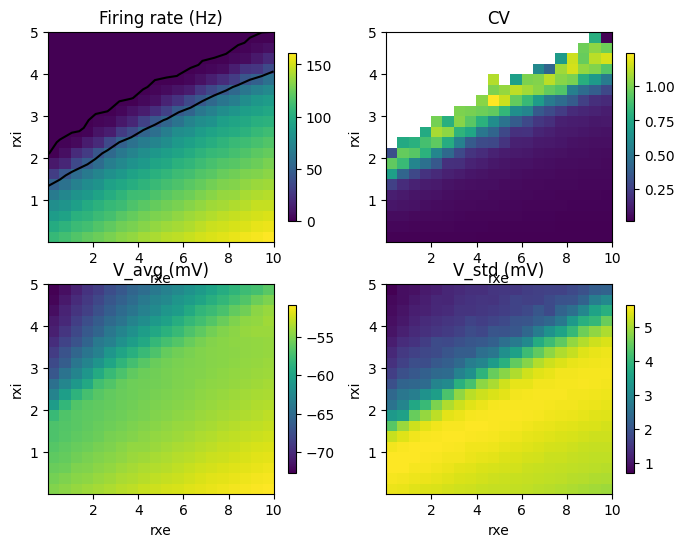

In [122]:
pop = pops_used[0]

def plot_2d_maps(pop):

    r = X['rate'].sel(pop=pop)
    cv = X['cv'].sel(pop=pop)
    vmin = X['vmin'].sel(pop=pop)
    vmax = X['vmax'].sel(pop=pop)
    vavg = X['vavg'].sel(pop=pop)
    vstd = X['vstd'].sel(pop=pop)

    plots = [
        ("Firing rate (Hz)", r),
        ("CV", cv),
        #("Vmin (mV)", vmin),
        #("Vmax (mV)", vmax),
        ("V_avg (mV)", vavg),
        ("V_std (mV)", vstd)
    ]

    k = 1e-3
    x0, x1 = float(r.rxe.min()) * k, float(r.rxe.max()) * k
    y0, y1 = float(r.rxi.min()) * k, float(r.rxi.max()) * k

    fig, axs = plt.subplots(2, 2, figsize=(8, 6))

    for ax, (title, da) in zip(axs.ravel(), plots):
        im = ax.imshow(da.T, extent=(x0, x1, y0, y1),
                    aspect='auto', origin='lower', interpolation='nearest')
        ax.set_title(title)
        ax.set_xlabel('rxe')
        ax.set_ylabel('rxi')
        fig.colorbar(im, ax=ax, shrink=0.8)

    rxi1, rxi2 = r.rxi.item(0), r.rxi.item(-1)
    rxe1 = r.isel(rxi=0).idxmax(dim='rxe').item()
    rxe2 = r.isel(rxi=-1).idxmax(dim='rxe').item()
    q1 = (rxe2 - rxe1) / (rxi2 - rxi1) * 1.1
    q0 = rxe1 - rxi1 * q1

    rxi_ = r.rxi.values
    rxe_ = q0 + rxi_ * q1
    #axs[0, 0].plot(rxe_ * k, rxi_ * k, 'k')

    print(f'{pop}:')
    #print(f'q0 = {q0}')
    #print(f'q1 = {q1}')

    r0 = [1, 50]
    for r0_ in r0:
        axs[0, 0].contour(
            r.rxe * k, r.rxi * k, (r - r0_).T,
            [0], colors='k'
        )

plot_2d_maps(pop)

In [85]:
64.408 - 64.88

-0.4719999999999942

Text(0.5, 1.0, 'CV, IT2')

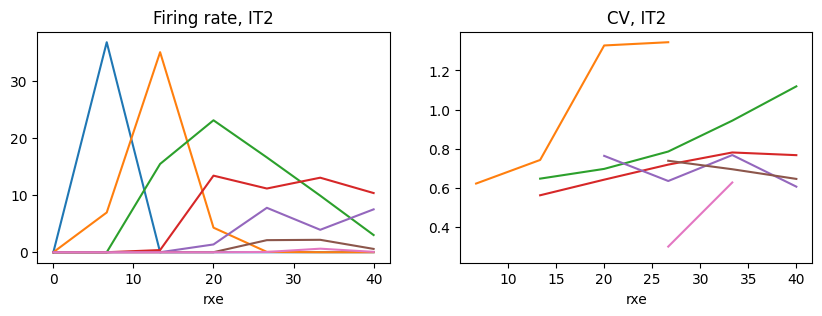

In [25]:
pop = pops_used[0]
rxi = X.rxi.item(0)

r = X['rate'].sel(pop=pop)
cv = X['cv'].sel(pop=pop)
vmin = X['vmin'].sel(pop=pop)
vmax = X['vmax'].sel(pop=pop)
vavg = X['vavg'].sel(pop=pop)

plt.figure(figsize=(10, 3))
for rxi in X.rxi.to_numpy():
    rxi_lbl = np.round(rxi / 1000, 1)
    plt.subplot(1, 2, 1)
    plt.plot(r.rxe / 1000, r.sel(rxi=rxi), label=f'rxi={rxi_lbl}')
    plt.subplot(1, 2, 2)
    plt.plot(r.rxe / 1000, cv.sel(rxi=rxi), label=f'rxi={rxi_lbl}')
    
plt.subplot(1, 2, 1)
plt.xlabel('rxe')
plt.title(f'Firing rate, {pop}')
#plt.legend()
plt.subplot(1, 2, 2)
plt.xlabel('rxe')
plt.title(f'CV, {pop}')
#plt.legend()

/tmp/ipykernel_182591/2086293218.py:41: RuntimeWarning: divide by zero encountered in divide
  rxe_r = (rxi_l - rxi1) / q + rxe1
/tmp/ipykernel_182591/2086293218.py:41: RuntimeWarning: invalid value encountered in divide
  rxe_r = (rxi_l - rxi1) / q + rxe1
/tmp/ipykernel_182591/2086293218.py:50: RuntimeWarning: invalid value encountered in scalar divide
  rxe_min = (rxi_min - rxi1) / q + rxe1
/tmp/ipykernel_182591/2086293218.py:51: RuntimeWarning: invalid value encountered in scalar divide
  rxe_max = (rxi_max - rxi1) / q + rxe1


ValueError: cannot convert float NaN to integer

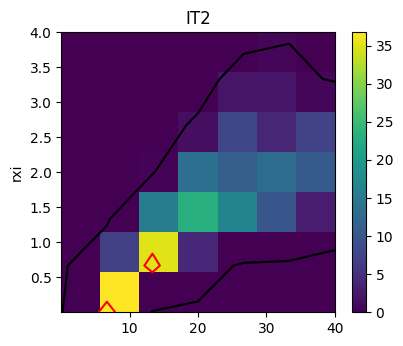

In [27]:
k = 1e-3
x0, x1 = float(X.rxe.min()) * k, float(X.rxe.max()) * k
y0, y1 = float(X.rxi.min()) * k, float(X.rxi.max()) * k

r0 = [1, 30]

regions = {}

plt.figure(figsize=(15, 8))

for n, pop in enumerate(pops_used):
    r = X['rate'].sel(pop=pop)

    plt.subplot(2, 3, n + 1)
    plt.imshow(r.T, extent=(x0, x1, y0, y1),
               aspect='auto', origin='lower', interpolation='nearest')
    plt.colorbar()
    plt.title(pop)
    if n in [3, 4, 5]:
        plt.xlabel('rxe')
    if n in [0, 3]:
        plt.ylabel('rxi')

    c = []
    cols = ['k', 'r']
    for m, r0_ in enumerate(r0):
        cc = plt.contour(r.rxe * k, r.rxi * k, (r - r0_).T, [0], colors=cols[m])
        cc = cc.allsegs[0]
        rxe_min_seg = [np.min(c_[:, 0]) for c_ in cc]
        seg_id = np.argmin(rxe_min_seg)
        c.append(cc[seg_id])

    cc = c[1]
    p1, p2 = np.argmin(cc[:, 0]), np.argmax(cc[:, 0])
    rxe1, rxi1 = cc[p1, 0], cc[p1, 1]
    rxe2, rxi2 = cc[p2, 0], cc[p2, 1]
    q = (rxi2 - rxi1) / (rxe2 - rxe1)
    q = np.round(q, 3).item()

    rxe_l, rxi_l = c[0][:, 0], c[0][:, 1]
    rxe_r = (rxi_l - rxi1) / q + rxe1
    d0 = np.max(rxe_r - rxe_l)

    marg_l, marg_r = 0.2, 0.2
    d = d0 * (1 + marg_l)
    rxe1 += d0 * marg_r
    rxe2 += d0 * marg_r

    rxi_min, rxi_max = y0, rxi2
    rxe_min = (rxi_min - rxi1) / q + rxe1
    rxe_max = (rxi_max - rxi1) / q + rxe1

    plt.plot([rxe_min, rxe_max], [rxi_min, rxi_max],
             'r.-', markersize=8)
    plt.plot([rxe_min - d, rxe_max - d], [rxi_min, rxi_max],
             'k.-', markersize=8)

    p = 10
    regions[pop] = {
        'rxe0': int(rxe_min / k / p) * p,
        'rxi0': int(rxi_min / k / p) * p,
        'q': q,
        'dmax': int(d / k / p) * p
    }

from pprint import pprint
pprint(regions)

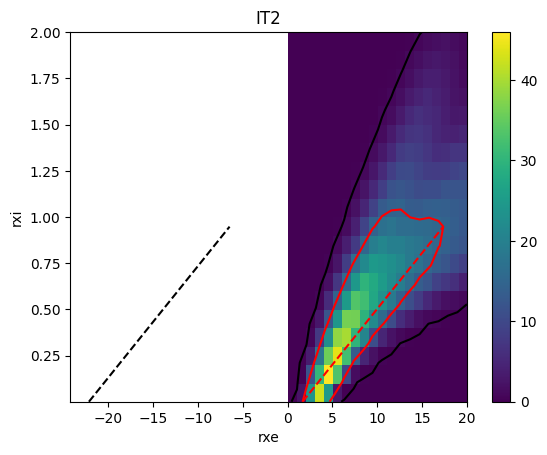

In [ ]:
pop = pops_used[0]

k = 1e-3
x0, x1 = float(X.rxe.min()) * k, float(X.rxe.max()) * k
y0, y1 = float(X.rxi.min()) * k, float(X.rxi.max()) * k

r0 = [1, 15]

plt.figure()

r = X['rate'].sel(pop=pop)

plt.imshow(r.T, extent=(x0, x1, y0, y1),
            aspect='auto', origin='lower',
            interpolation='nearest')
plt.colorbar()
plt.title(pop)
plt.xlabel('rxe')
plt.ylabel('rxi')

C = []
cols = ['k', 'r']
for n, r0_ in enumerate(r0):
    c = plt.contour(r.rxe * k, r.rxi * k, (r - r0_).T, [0], colors=cols[n])
    C.append(c)

c = []
for m in range(2):
    cc = C[m].allsegs[0]
    rxe_min_seg = [np.min(c_[:, 0]) for c_ in cc]
    seg_id = np.argmin(rxe_min_seg)
    c.append(cc[seg_id])

cc = c[1]
p1, p2 = np.argmin(cc[:, 0]), np.argmax(cc[:, 0])
rxe1, rxi1 = cc[p1, 0], cc[p1, 1]
rxe2, rxi2 = cc[p2, 0], cc[p2, 1]
q = (rxi2 - rxi1) / (rxe2 - rxe1)

rxe_l, rxi_l = c[0][:, 0], c[0][:, 1]
rxe_r = (rxi_l - rxi1) / q + rxe1
d = np.max(rxe_r - rxe_l) * 1.2

plt.plot([rxe1, rxe2], [rxi1, rxi2], 'r--')
plt.plot([rxe1 - d, rxe2 - d], [rxi1, rxi2], 'k--')

In [ ]:
c = C[1].allsegs[0]
#print(c)
rxe_min_seg = [np.min(c_[:, 0]) for c_ in c]
print(rxe_min_seg)
seg_id = np.argmin(rxe_min_seg)
c = c[seg_id]
print(c)

p1, p2 = np.argmin(c[:, 0]), np.argmax(c[:, 0])
rxe1, rxi1 = c[p1, 0], c[p1, 1]
rxe2, rxi2 = c[p2, 0], c[p2, 1]
print(f'rxe1={rxe1}, rxi1={rxi1}')
print(f'rxe2={rxe2}, rxi2={rxi2}')

[np.float64(1.678218400562028)]
[[4.69018922e+00 1.00000000e-03]
 [5.26389474e+00 4.27619253e-02]
 [6.08092358e+00 1.06210526e-01]
 [6.31647368e+00 1.30927520e-01]
 [7.28140087e+00 2.11421053e-01]
 [7.36905263e+00 2.21187787e-01]
 [8.42163158e+00 2.78627923e-01]
 [9.03684394e+00 3.16631579e-01]
 [9.47421053e+00 3.55548101e-01]
 [1.05267895e+01 4.14288026e-01]
 [1.06922430e+01 4.21842105e-01]
 [1.15793684e+01 4.76109180e-01]
 [1.24870756e+01 5.27052632e-01]
 [1.26319474e+01 5.40024203e-01]
 [1.36845263e+01 6.04035944e-01]
 [1.42000215e+01 6.32263158e-01]
 [1.47371053e+01 6.73522188e-01]
 [1.57896842e+01 7.27185240e-01]
 [1.59838247e+01 7.37473684e-01]
 [1.68422632e+01 8.36181346e-01]
 [1.69753250e+01 8.42684211e-01]
 [1.73713974e+01 9.47894737e-01]
 [1.68422632e+01 9.78989797e-01]
 [1.57896842e+01 9.96221493e-01]
 [1.47371053e+01 9.86653723e-01]
 [1.36845263e+01 9.98072065e-01]
 [1.26319474e+01 1.04074396e+00]
 [1.15793684e+01 1.03585530e+00]
 [1.05267895e+01 1.00430354e+00]
 [9.7030584

In [ ]:
# extract contour segments from QuadContourSet `c`
contour_points = {
    float(level): [np.asarray(seg) for seg in segs]
    for level, segs in zip(c.levels, c.allsegs)
}

# optional: stacked arrays per level (all segments concatenated)
contour_points_stacked = {
    lvl: (np.vstack(segs) if len(segs) else np.empty((0, 2)))
    for lvl, segs in contour_points.items()
}

# inspect
list(contour_points.keys()), {lvl: [s.shape for s in segs] for lvl, segs in contour_points.items()}

AttributeError: 'numpy.ndarray' object has no attribute 'levels'

### Stuff

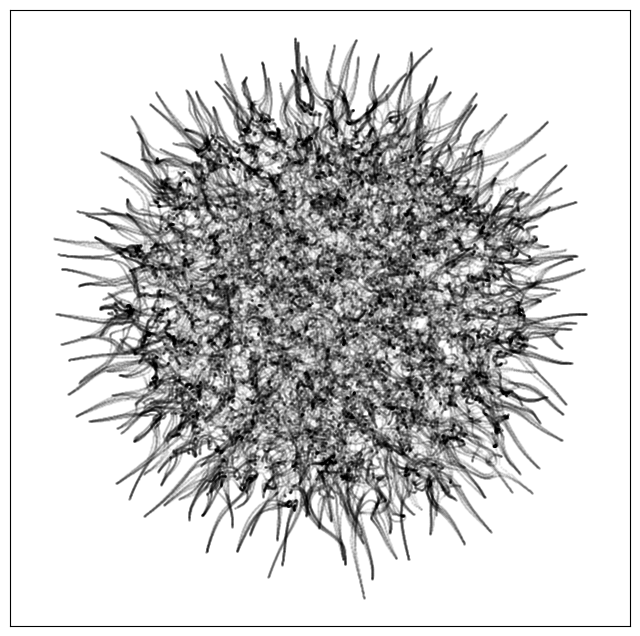

In [53]:
from numpy.random import randn

N = 200   # matrix size
M = 300   # num. of interpolation steps

K = 5    # num. of random perturbation
d = 0.07   # perturbation amplitude

sz = (N, N)
X1 = randn(*sz) + 1j * randn(*sz)
X2 = randn(*sz) + 1j * randn(*sz)

dX = randn(*sz, K) + 1j * randn(*sz, K)

L = []
for m in range(M):
    a = m / M
    r = 1 - 4 * (a - 0.5)**2
    for k in range(K):
        X = a * X1 + (1 - a) * X2 + d * dX[:, :, k] * r
        #X = a * (X1 + d * dX[:, :, k]) + (1 - a) * X2
        L.append(np.linalg.eigvals(X))
L = np.asarray(L).ravel()

plt.figure(figsize=(8, 8))
plt.plot(np.real(L), np.imag(L), 'k.', alpha=0.05, markersize=2)
plt.axis('equal')
s = 4
#plt.xlim(-s, s)
#plt.ylim(-s, s)
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()